In [1]:
!hostname

gnode011.cluster


In [2]:
!nvidia-smi

Tue Apr 15 17:33:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:31:00.0 Off |                    0 |
| N/A   30C    P0             62W /  300W |       4MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import itertools as it
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sdeint
from toolbox import (
    make_loss,
    StatLoss,
    SINN,
    FPU
)
import time

In [4]:
torch.cuda.is_available()

True

In [5]:
device = torch.device('cuda')

In [6]:
print(torch.__version__)
print(torch.version.cuda)

2.0.1+cu118
11.8


In [7]:
seed = 1234
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

Probability of x <= 0: 0.5938
Probability of x > 0: 0.4062


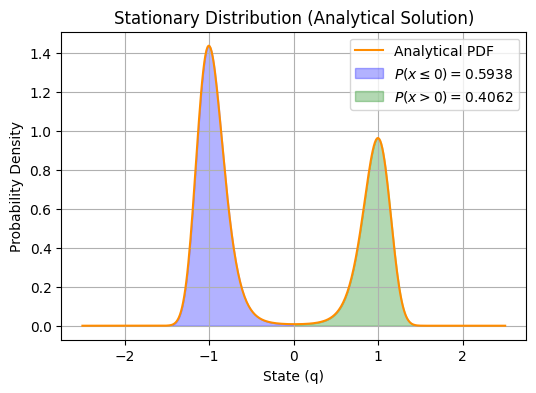

In [8]:
from scipy.integrate import quad

# Parameters
A = 0.01                  # Driving strength
D = 1/20                  # Fluctuation strength
sec_length = 400           # Length of the input sequence

# Define x-range for normalization
x = np.linspace(-2.5, 2.5, sec_length)

# Compute the unnormalized PDF over the x-range
def unnormalized_pdf(x, D, A):
    potential = -0.5 * x**2 + 0.25 * x**4 + A * x
    return np.exp(-potential / D)

# Compute the normalization constant Z
pdf_unnormalized = unnormalized_pdf(x, D, A)
Z = np.trapz(pdf_unnormalized, x)

# Define the normalized PDF
def analytical_pdf(x, D, A):
    return unnormalized_pdf(x, D, A) / Z

pdf_exact = analytical_pdf(x, D, A)

# Define the integrand for quad
def integrand(x):
    return analytical_pdf(x, D, A)

# Compute probabilities
# Probability of x <= 0
P_x_le_0, _ = quad(integrand, -np.inf, 0)

# Probability of x > 0
P_x_gt_0, _ = quad(integrand, 0, np.inf)

# Print results
print(f"Probability of x <= 0: {P_x_le_0:.4f}")
print(f"Probability of x > 0: {P_x_gt_0:.4f}")


# Plot analytical stationary distribution
plt.figure(figsize=(6, 4))
plt.plot(x, pdf_exact, color='darkorange', label='Analytical PDF')
# Shade the left half (x <= 0)
plt.fill_between(x[x <= 0], pdf_exact[x <= 0], color='blue', alpha=0.3,
                 label=f'$P(x \leq 0) = {P_x_le_0:.4f}$')

# Shade the right half (x > 0)
plt.fill_between(x[x > 0], pdf_exact[x > 0], color='green', alpha=0.3,
                 label=f'$P(x > 0) = {P_x_gt_0:.4f}$')
plt.xlabel("State (q)")
plt.ylabel("Probability Density")
plt.title("Stationary Distribution (Analytical Solution)")
plt.grid(True)
plt.legend()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Omega = 1.0                # Frequency of the oscillation
gamma = 1.0                # Damping coefficient
dt= 0.001                  # Step-size of the SDE solver 
delta_t= 1.0               # Step-size of the temporally coarse-grained path
batch = 400                # Batch size 


### SDE solver (EM scheme), 
Time = 5*delta_t*sec_length
print(Time)
length=int(Time/dt)+1
t = np.linspace(0, Time, length) # define time axis
gap=int(delta_t/dt)
t_store=t[0:-1:gap]
q_store = np.zeros([t_store.size+1,batch])

# Generate uniform random numbers in [0, 1] for the batch
r = np.random.rand(batch)

# Set initial condition based on probabilities
q = np.zeros((2, batch))
q[0, :] = -1
# q[0, :] = np.where(r <= P_x_le_0, -1, 1)  # x_0 = -1 with Probability of x <= 0, x_0 = 1 with Probability of x > 0

# Print the first 10 initial conditions to verify
print("First 10 initial conditions:")
print(q[0, :10])

# Potential function and its derivative
def V(x, t, A, Omega):
    return -0.5 * x**2 + 0.25 * x**4 + A * x

def dV_dx(x, t, A, Omega):
    return -x + x**3 + A

# Solve SDE using Euler Maruyama scheme
j=1
for i in range(1,length):
     q[1,:] = q[0,:] - dV_dx(q[0,:],i*dt,A,Omega)*dt + np.random.randn(1,batch)*np.sqrt(2*dt*D)
     
     if i % gap ==0:            
        q_store[j,:]=q[1,:]
        j=j+1
    
     q[0,:]=q[1,:]

Toss=int(t_store.size/2)          
q_store=q_store[Toss:-1,:]         
print(q_store.shape)



2000.0
First 10 initial conditions:
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
(1000, 400)


Text(0.5, 1.0, 'Solution of the Transtion dynamics')

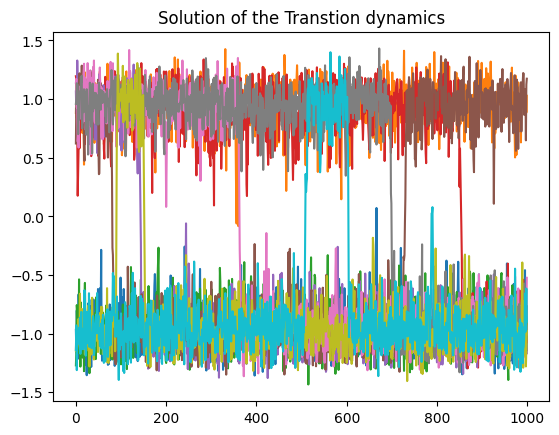

In [10]:
plt.figure(1)
for i in range(10):
    plt.plot(t_store[Toss:]-t_store[Toss],q_store[:,i])
# plt.legend()
plt.title("Solution of the Transtion dynamics")

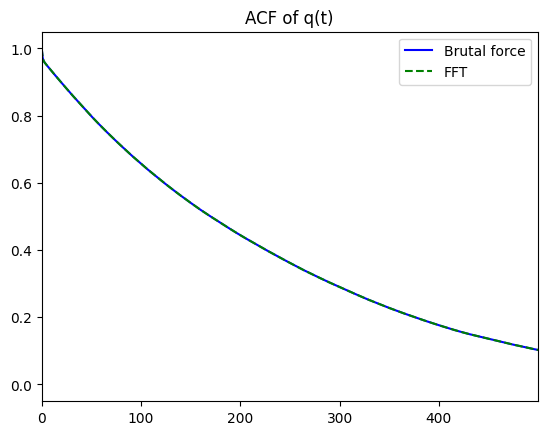

In [11]:
## Calculating the acf for q(t) by brutal force
Traj1=q_store
T_acf=t_store[0:Traj1.shape[0]]
acf_u=StatLoss.acf(torch.from_numpy(Traj1.reshape(Traj1.shape[0], batch,1)),method='bruteforce')
acf_u_fft=StatLoss.acf(torch.from_numpy(Traj1.reshape(Traj1.shape[0], batch,1)))
corr_u=acf_u.mean(axis=1).detach().cpu().numpy()
corr_u_fft=acf_u_fft.mean(axis=1).detach().cpu().numpy()
plt.figure(1)      
plt.plot(T_acf, corr_u,'b',label='Brutal force')
plt.plot(T_acf, corr_u_fft,'g--',label='FFT')
plt.title('ACF of q(t)')
plt.xlim([0,T_acf[-1]/2])
plt.legend()
plt.show()

In [12]:
#####################  Construct the sample traj for SINN learning 
ini=np.random.randn(sec_length,batch)
Traj=q_store[-sec_length:,:]
T=np.arange(len(Traj[:,1]))*delta_t
print(ini.shape, Traj.shape)

(400, 400) (400, 400)


In [13]:
# Reformulating data into Torch tensors 
# Input of SINN should be of the form (seq_len, batch, input_size)

ini = np.random.randn(2*sec_length,batch).astype(np.float32) 
input = torch.from_numpy(ini.reshape(2*sec_length, batch,1)).to(device)
batch_validation = batch
val_set = torch.normal(0.0, 1.0, (2*sec_length, batch_validation, 1), device=device)

# input of the LSTM should be of the form (seq_len, batch, input_size)
Traj = Traj.astype(np.float32) 
target = torch.from_numpy(Traj.reshape(sec_length, batch, 1)).to(device)
PDF_exact=torch.from_numpy(pdf_exact).to(device)
print('The torch input size is', input.size(), input.dtype)
print('The torch validation size is', val_set.size(), val_set.dtype)
print('The torch target size is', target.size(), target.dtype)

The torch input size is torch.Size([800, 400, 1]) torch.float32
The torch validation size is torch.Size([800, 400, 1]) torch.float32
The torch target size is torch.Size([400, 400, 1]) torch.float32


In [14]:
# Defining Loss functions

LAGS = 400
N = sec_length
# loss_acf_fft = make_loss('acf[fft]', target, lags=LAGS, device=device)
# loss_acf_q2 = make_loss('acf[fft]', target**2, lags=LAGS, device=device)
# loss_acf_bruteforce = make_loss('acf[bruteforce]', target, lags=LAGS, device=device)
# loss_acf_randbrute = make_loss('acf[randombrute]', target, lags=LAGS, sample_lags=20, device=device)
loss_pdf_empirical = make_loss('pdf', target, lower=-2.5, upper=2.5, n=N, bw=0.1, device=device)
# loss_pdf_exact = make_loss('pdf', PDF_exact, lower=-5, upper=5, n=N, bw=None, device=device)

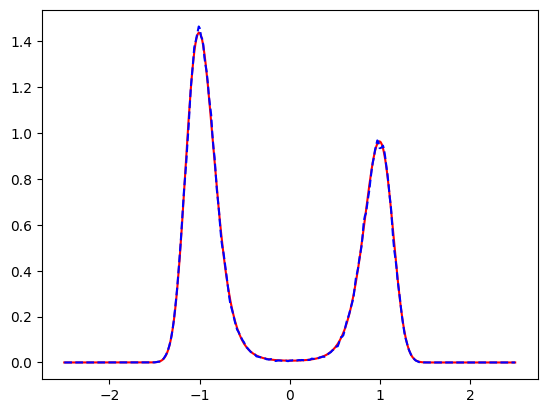

In [15]:
plt.plot(x, pdf_exact, 'r')
plt.plot(x, loss_pdf_empirical._target.cpu(),'b--')

In [16]:
pdf = loss_pdf_empirical._target.cpu()

In [17]:
# Flatten the pdf tensor to 1D
pdf = pdf.flatten()
# Define the grid bounds and number of points
lower = -2.5  # Lower bound of the grid
upper = 2.5    # Upper bound of the grid
n = pdf.shape[0]  # Number of grid points

# Compute the grid spacing
grid_spacing = (upper - lower) / (n - 1)

# Compute the AUC using the trapezoidal rule
auc = torch.trapz(pdf, dx=grid_spacing)

print(f"Area under the curve (AUC): {auc.item()}")

Area under the curve (AUC): 0.9999999403953552


In [18]:
# Compute the AUC using the trapezoidal rule
auc_exact = np.trapz(pdf_exact, dx=grid_spacing)

In [19]:
auc_exact

0.9999999999999999

In [20]:
pdf_exact_np = np.array(pdf_exact)
pdf_empirical_np = np.array(pdf)
pdf_exact_np = pdf_exact_np.reshape(pdf_empirical_np.shape)

# Compute the difference
difference = pdf_exact_np - pdf_empirical_np

# Compute the L2 norm of the difference
l2_norm = np.linalg.norm(difference, ord=2)

print("L2 norm of the difference:", l2_norm)

L2 norm of the difference: 0.13367965138413251


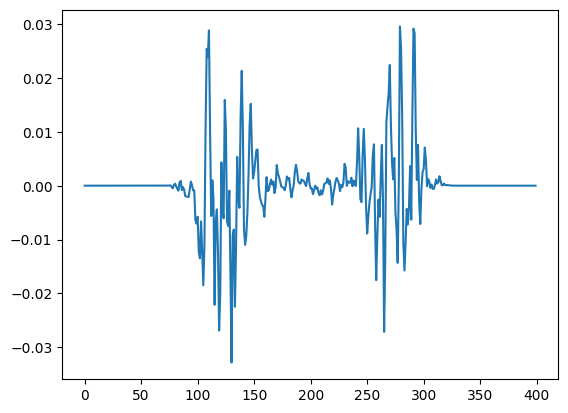

In [21]:
plt.plot(difference)